# Setup and Data Loading

In [1]:
%pip install matplotlib

import math 
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statistics import mean, median, stdev

You should consider upgrading via the '/Users/christophstein/Documents/jku/qcs-rl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
LOG_DIR = "logs"

In [3]:
train_df = pd.read_csv(f"{LOG_DIR}/eval.monitor.csv", skiprows=1)
train_df.head()

,r,l,t
0,-180.01,10,32.402992
1,-200.00,10,32.406021
2,-200.00,10,32.408378
3,-200.00,10,32.410877
4,1000.00,1,32.411514


In [4]:
EPISODE_CUTOFF = 10 # must be same as in training code.

# Data Preparation

In [5]:
def compute_success_rate(data: pd.DataFrame) -> float:
    return len(data[data < EPISODE_CUTOFF]) / len(data)

In [6]:
print(train_df.columns)
train_df["steps"] = train_df["l"].cumsum(axis=0)

# moving average over episode rewards
train_df["r_avg"] = train_df["r"].rolling(50).mean()

# moving average over (circuit) length
train_df["l_avg"] = train_df["l"].rolling(50).mean()

# compute success percentage

train_df["succ_pct"] = train_df["l"].rolling(50).aggregate(
    compute_success_rate
)

train_df.head()

Index(['r', 'l', 't'], dtype='object')


,r,l,t,steps,r_avg,l_avg,succ_pct
0,-180.01,10,32.402992,10,NaN,NaN,NaN
1,-200.00,10,32.406021,20,NaN,NaN,NaN
2,-200.00,10,32.408378,30,NaN,NaN,NaN
3,-200.00,10,32.410877,40,NaN,NaN,NaN
4,1000.00,1,32.411514,41,NaN,NaN,NaN


In [7]:
# Select every nth datapoint to avoid plot clutter
train_df = train_df[train_df.index % 100 == 0]

# Data Analysis

## Plot Reward over Steps 

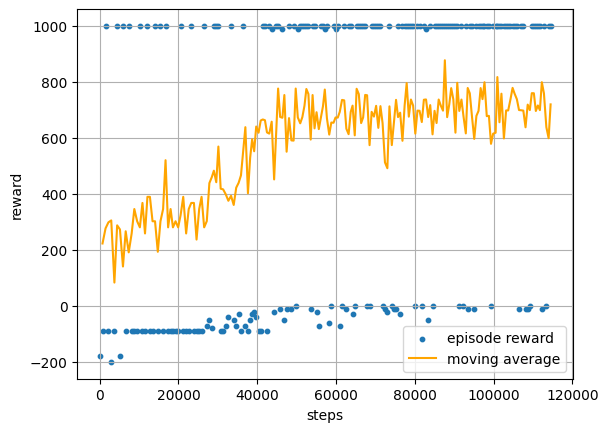

In [8]:
ax = plt.subplot()


ax.scatter(train_df["steps"], train_df["r"], label="episode reward", s=10)
ax.plot(train_df["steps"], train_df["r_avg"], label="moving average", c="orange")

ax.set_xlabel("steps")
ax.set_ylabel("reward")

plt.legend()
plt.grid()
plt.show()

## Plot Circuit Length over Steps

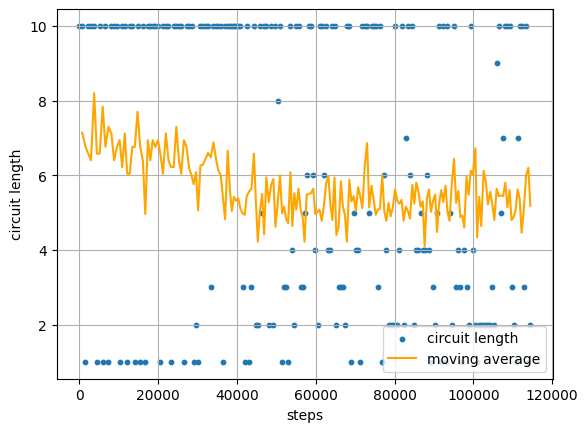

In [9]:
ax = plt.subplot()


ax.scatter(train_df["steps"], train_df["l"], label="circuit length", s=10)
ax.plot(train_df["steps"], train_df["l_avg"], label="moving average", c="orange")

ax.set_xlabel("steps")
ax.set_ylabel("circuit length")

plt.legend()
plt.grid()
plt.show()

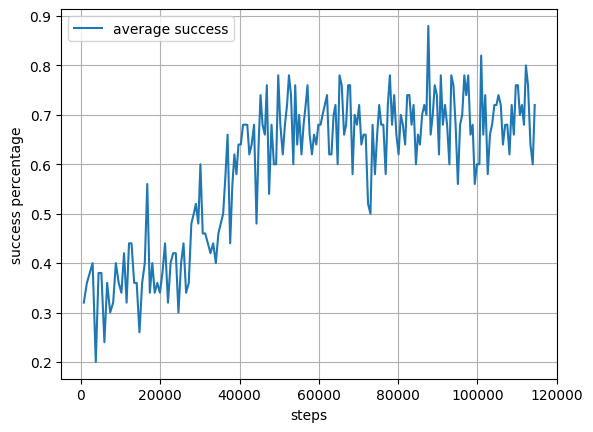

In [10]:
ax = plt.subplot()

ax.plot(train_df["steps"], train_df["succ_pct"], label="average success")

ax.set_xlabel("steps")
ax.set_ylabel("success percentage")

plt.legend()
plt.grid()
plt.show()